### Price elasticity experiments
* run on the real 2015 to 2017 bookings of the two hotels, kept as the reference of what the real data supports
* demand response along the booking curve: daily pickup for an arrival week against the rate offered that day, within hotel, arrival week and segment cells
* controls for what the pricer sees: rooms already on the books, days to arrival, booking weekday, holidays and attention in the source markets
* year over year specification, placebo with a future rate, stability across hotels and seasons, bootstrap intervals

In [1]:
import os
import json
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
warnings.filterwarnings("ignore")

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
PARQUET_PATH = os.path.join(ROOT_DIR, "data", "parquet", "bookings.parquet")
HOLIDAYS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "holidays.parquet")
PAGEVIEWS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "pageviews.parquet")
MODELS_DIR = os.path.join(ROOT_DIR, "data", "models")
segments = ["Online TA", "Offline TA/TO", "Direct"]
min_cell_days = 20
bootstrap_rounds = 200
rng = np.random.default_rng(7)

In [2]:
# bookings with typed dates, cleaned rates and the arrival week
def load_bookings(path):
    frame = pd.read_parquet(path)
    for col in ["arrival_date", "booking_date", "leave_books_date"]:
        frame[col] = pd.to_datetime(frame[col])
    frame = frame[(frame["adr"] > 10) & (frame["adr"] < 1000) & (frame["nights"] > 0) & frame["market_segment"].isin(segments) & (frame["lead_time"] <= 365)]
    frame["arrival_week"] = frame["arrival_date"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
    return frame

In [3]:
# daily pickup panel: bookings made per day for each hotel, segment and arrival week, with the mean rate of those bookings
def pickup_panel(frame):
    grp = frame.groupby(["hotel", "market_segment", "arrival_week", "booking_date"])
    panel = grp.agg(pickup=("booking_id", "size"), room_nights=("nights", "sum"), rate=("adr", "mean"), lead=("lead_time", "mean")).reset_index()
    panel["days_to_arrival"] = (panel["arrival_week"] - panel["booking_date"]).dt.days
    panel["booking_dow"] = panel["booking_date"].dt.dayofweek
    panel["log_pickup"] = np.log(panel["pickup"])
    panel["log_rate"] = np.log(panel["rate"])
    return panel

In [4]:
# rooms already on the books for the arrival week at the start of each booking day, the pressure the pricer sees
def add_on_books(panel, frame):
    frame = frame.sort_values("booking_date")
    out = []
    for (hotel, week), part in panel.groupby(["hotel", "arrival_week"]):
        rows = frame[(frame["hotel"] == hotel) & (frame["arrival_week"] == week)]
        booked = rows["booking_date"].values
        leaves = rows["leave_books_date"].values
        days = part["booking_date"].values
        otb = np.array([int(((booked < d) & (leaves > d)).sum()) for d in days])
        pace = np.array([int(((booked >= d - np.timedelta64(7, "D")) & (booked < d)).sum()) for d in days])
        out.append(part.assign(on_books=otb, pace_7d=pace))
    return pd.concat(out, ignore_index=True)

In [5]:
# holiday counts in the booker markets and attention index per arrival week and per booking week
def add_demand_shifters(panel, holidays_path, pageviews_path):
    hol = pd.read_parquet(holidays_path)
    hol["date"] = pd.to_datetime(hol["date"])
    hol = hol[hol["kind"] == "public"]
    hol["week"] = hol["date"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
    counts = hol.groupby("week").size()
    panel["holidays_arrival_week"] = panel["arrival_week"].map(counts).fillna(0)
    pv = pd.read_parquet(pageviews_path)
    pv["date"] = pd.to_datetime(pv["date"])
    pv = pv[pv["project"].isin(["en.wikipedia", "de.wikipedia", "fr.wikipedia", "es.wikipedia", "pt.wikipedia"])]
    weekly = np.log(pv.groupby(pv["date"].dt.to_period("W-SUN").dt.end_time.dt.normalize())["views"].sum())
    panel["attention_booking_week"] = panel["booking_date"].dt.to_period("W-SUN").dt.end_time.dt.normalize().map(weekly)
    panel["attention_booking_week"] = panel["attention_booking_week"].fillna(weekly.mean())
    return panel

In [6]:
# fit one specification and return the rate coefficient with a cluster robust standard error
def fit(panel, formula, cluster):
    model = smf.ols(formula, data=panel).fit(cov_type="cluster", cov_kwds={"groups": panel[cluster]})
    return {"elasticity": round(float(model.params["log_rate"]), 3), "se": round(float(model.bse["log_rate"]), 3), "p": round(float(model.pvalues["log_rate"]), 4), "n": int(model.nobs), "r2": round(float(model.rsquared), 3)}

In [7]:
# specifications from naive to fully controlled
def specifications():
    return {
        "naive": "log_pickup ~ log_rate + C(hotel) + C(market_segment)",
        "week fixed effects": "log_pickup ~ log_rate + C(hotel):C(market_segment):C(arrival_week)",
        "week fe and booking timing": "log_pickup ~ log_rate + np.log1p(days_to_arrival) + C(booking_dow) + C(hotel):C(market_segment):C(arrival_week)",
        "week fe, timing and pressure": "log_pickup ~ log_rate + np.log1p(days_to_arrival) + C(booking_dow) + np.log1p(on_books) + np.log1p(pace_7d) + C(hotel):C(market_segment):C(arrival_week)",
        "full with demand shifters": "log_pickup ~ log_rate + np.log1p(days_to_arrival) + C(booking_dow) + np.log1p(on_books) + np.log1p(pace_7d) + attention_booking_week + C(hotel):C(market_segment):C(arrival_week)",
    }

In [8]:
# year over year specification: change in weekly room nights against change in weekly rate for the same arrival week and segment
def yoy_spec(frame):
    weekly = frame.groupby(["hotel", "market_segment", "arrival_week"]).agg(room_nights=("nights", "sum"), rate=("adr", "mean"), bookings=("booking_id", "size")).reset_index()
    weekly = weekly[weekly["bookings"] >= 10]
    weekly["week_ly"] = weekly["arrival_week"] - pd.Timedelta(weeks=52)
    merged = weekly.merge(weekly, left_on=["hotel", "market_segment", "week_ly"], right_on=["hotel", "market_segment", "arrival_week"], suffixes=("", "_ly"))
    merged["d_log_q"] = np.log(merged["room_nights"]) - np.log(merged["room_nights_ly"])
    merged["d_log_p"] = np.log(merged["rate"]) - np.log(merged["rate_ly"])
    merged["month"] = merged["arrival_week"].dt.month
    model = smf.ols("d_log_q ~ d_log_p + C(hotel):C(market_segment) + C(month)", data=merged).fit(cov_type="HC1")
    return {"elasticity": round(float(model.params["d_log_p"]), 3), "se": round(float(model.bse["d_log_p"]), 3), "p": round(float(model.pvalues["d_log_p"]), 4), "n": int(model.nobs)}

In [9]:
# placebo: the rate offered seven days later should not move today's pickup once the week is fixed
def placebo(panel):
    shifted = panel.sort_values(["hotel", "market_segment", "arrival_week", "booking_date"]).copy()
    shifted["future_rate"] = shifted.groupby(["hotel", "market_segment", "arrival_week"])["log_rate"].shift(-7)
    part = shifted.dropna(subset=["future_rate"])
    formula = "log_pickup ~ future_rate + log_rate + np.log1p(days_to_arrival) + C(booking_dow) + np.log1p(on_books) + np.log1p(pace_7d) + C(hotel):C(market_segment):C(arrival_week)"
    model = smf.ols(formula, data=part).fit(cov_type="cluster", cov_kwds={"groups": part["arrival_week"]})
    return {"future_rate_coef": round(float(model.params["future_rate"]), 3), "future_rate_p": round(float(model.pvalues["future_rate"]), 4), "current_rate_coef": round(float(model.params["log_rate"]), 3), "n": int(model.nobs)}

In [10]:
# the full specification per hotel and per season
def stability(panel, formula):
    rows = []
    panel = panel.assign(season=np.where(panel["arrival_week"].dt.month.isin([6, 7, 8, 9]), "high", np.where(panel["arrival_week"].dt.month.isin([4, 5, 10]), "shoulder", "low")))
    for key, part in list(panel.groupby("hotel")) + list(panel.groupby("season")) + list(panel.groupby("market_segment")):
        if part["arrival_week"].nunique() < 20:
            continue
        r = fit(part, formula, "arrival_week")
        r["group"] = key
        rows.append(r)
    return pd.DataFrame(rows)

In [11]:
# cluster bootstrap of the full specification over arrival weeks
def bootstrap(panel, formula, rounds):
    weeks = panel["arrival_week"].unique()
    values = []
    for i in range(rounds):
        pick = rng.choice(weeks, size=len(weeks), replace=True)
        sample = pd.concat([panel[panel["arrival_week"] == w] for w in pick], ignore_index=True)
        try:
            model = smf.ols(formula, data=sample).fit()
            values.append(float(model.params["log_rate"]))
        except Exception:
            continue
    return float(np.percentile(values, 2.5)), float(np.percentile(values, 97.5))

In [12]:
# pickup against rate after removing the cell means, the picture behind the coefficient
def plot_within(panel):
    part = panel.copy()
    keys = ["hotel", "market_segment", "arrival_week"]
    part["rate_dm"] = part["log_rate"] - part.groupby(keys)["log_rate"].transform("mean")
    part["pickup_dm"] = part["log_pickup"] - part.groupby(keys)["log_pickup"].transform("mean")
    bins = pd.qcut(part["rate_dm"], 20, labels=False, duplicates="drop")
    curve = part.groupby(bins).agg(rate=("rate_dm", "mean"), pickup=("pickup_dm", "mean"))
    plt.figure(figsize=(7, 4))
    plt.scatter(part["rate_dm"], part["pickup_dm"], s=3, color="lightgray", alpha=0.3)
    plt.plot(curve["rate"], curve["pickup"], marker="o", color="blue")
    plt.xlabel("log rate, deviation from the arrival week mean")
    plt.ylabel("log pickup, deviation from the arrival week mean")
    plt.title("Pickup against rate within arrival weeks")
    plt.show()

In [13]:
# save the estimates
def export(results, yoy, plac, stab, ci):
    os.makedirs(MODELS_DIR, exist_ok=True)
    out = {"specifications": results, "year_over_year": yoy, "placebo": plac, "stability": stab.to_dict("records"), "bootstrap_ci": {"low": round(ci[0], 3), "high": round(ci[1], 3)}, "generated_at": datetime.datetime.now(datetime.timezone.utc).isoformat()}
    with open(os.path.join(MODELS_DIR, "experiments_elasticity.json"), "w") as f:
        json.dump(out, f, indent=1)
    print("saved " + os.path.join(MODELS_DIR, "experiments_elasticity.json"))

In [14]:
frame = load_bookings(PARQUET_PATH)
panel = pickup_panel(frame)
panel = add_on_books(panel, frame)
panel = add_demand_shifters(panel, HOLIDAYS_PATH, PAGEVIEWS_PATH)
cells_ok = panel.groupby(["hotel", "market_segment", "arrival_week"])["booking_date"].transform("size") >= min_cell_days
panel = panel[cells_ok].reset_index(drop=True)
print("panel rows " + str(len(panel)) + ", arrival weeks " + str(panel["arrival_week"].nunique()) + ", cells " + str(panel.groupby(["hotel", "market_segment", "arrival_week"]).ngroups))
results = {}
for name, formula in specifications().items():
    results[name] = fit(panel, formula, "arrival_week")
    print(name + ": " + json.dumps(results[name]))

panel rows 34998, arrival weeks 114, cells 588


naive: {"elasticity": -0.018, "se": 0.012, "p": 0.1312, "n": 34998, "r2": 0.056}


week fixed effects: {"elasticity": 0.105, "se": 0.018, "p": 0.0, "n": 34998, "r2": 0.108}


week fe and booking timing: {"elasticity": -0.032, "se": 0.018, "p": 0.0805, "n": 34998, "r2": 0.154}


week fe, timing and pressure: {"elasticity": -0.007, "se": 0.019, "p": 0.7187, "n": 34998, "r2": 0.172}


full with demand shifters: {"elasticity": -0.01, "se": 0.019, "p": 0.6053, "n": 34998, "r2": 0.172}


In [15]:
yoy = yoy_spec(frame)
print("year over year: " + json.dumps(yoy))
plac = placebo(panel)
print("placebo: " + json.dumps(plac))
full = specifications()["full with demand shifters"]
stab = stability(panel, full)
print(stab.to_string(index=False))

year over year: {"elasticity": 0.497, "se": 0.252, "p": 0.0486, "n": 366}


placebo: {"future_rate_coef": -0.0, "future_rate_p": 0.986, "current_rate_coef": -0.015, "n": 30882}


 elasticity    se      p     n    r2         group
      0.075 0.033 0.0210 19401 0.145    City Hotel
     -0.078 0.020 0.0001 15597 0.138  Resort Hotel
     -0.039 0.028 0.1655 16341 0.145          high
      0.044 0.033 0.1904  9350 0.232           low
     -0.006 0.032 0.8531  9307 0.158      shoulder
     -0.124   NaN    NaN  5926 0.182        Direct
      0.180 0.044 0.0000  6890 0.135 Offline TA/TO
     -0.106 0.021 0.0000 22182 0.207     Online TA


bootstrap 95 percent interval of the full specification -0.046 to 0.026


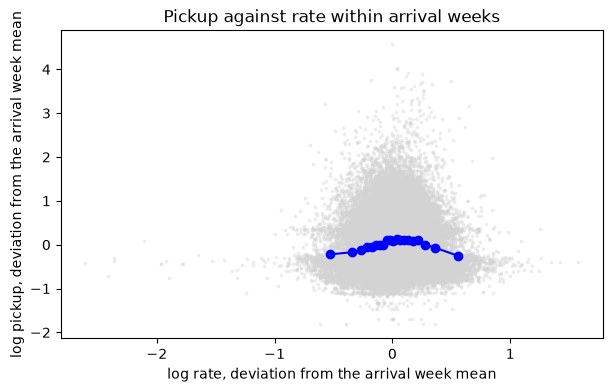

saved /srv/data/models/experiments_elasticity.json


In [16]:
ci = bootstrap(panel, full, bootstrap_rounds)
print("bootstrap 95 percent interval of the full specification " + str(round(ci[0], 3)) + " to " + str(round(ci[1], 3)))
plot_within(panel)
export(results, yoy, plac, stab, ci)